# Facial Expression Recognition (FER) — Complete Training & Submission

**Task:** classify 48×48 grayscale face crops into one of 7 emotions:
`angry, disgust, fear, happy, neutral, sad, surprise`.

**Data:** 28,709 labelled images (`train.csv` + `train/`) and 7,178 unlabelled
images (`test.csv` + `test/`) that must be predicted and submitted as
`id,label`.

**How this notebook is organised**
1. Setup and data loading
2. Exploratory analysis (class distribution, sample images)
3. Preprocessing — normalization statistics computed **from train images only**
4. Train/validation split — carved **from `train.csv` only**
5. Models — a small CNN baseline and a pretrained ResNet18
6. Training loop — full code shown; run here for 2 epochs as a demo; the same
   code was run for 22 epochs (two seeds) to produce the saved checkpoints used
   for the final results below
7. Validation results (per model, with test-time augmentation)
8. Confusion matrix and per-class statistics
9. Final ensemble → writes `submission_final.csv`
10. Sample predictions
11. Summary

> **No lookahead bias:** the test set is touched exactly once, at the very end,
> to write the submission. It is never used for training, validation, early
> stopping, normalization statistics, or any other design decision.

## 1. Setup

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
print('torch', torch.__version__, '| torchvision', torchvision.__version__)
print('MPS available:', torch.backends.mps.is_available())
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

torch 2.8.0 | torchvision 0.23.0
MPS available: True
device: mps


## 2. Data loading

Images are decoded once and kept in memory as uint8 arrays (28,709 × 48 × 48 is only ~66 MB).

In [2]:
df = pd.read_csv('train.csv')
print('train.csv shape:', df.shape)
print(df.head(3).to_string(index=False))
print()
print('test.csv shape:', pd.read_csv('test.csv').shape)

CACHE_TRAIN = 'train_preloaded.pt'
if os.path.exists(CACHE_TRAIN):
    c = torch.load(CACHE_TRAIN, weights_only=False)
    ids, imgs, labels = c['ids'], c['images'], c['labels']
    print(f'\nLoaded {len(ids)} decoded train images from cache ({CACHE_TRAIN}).')
else:
    images, labs = [], []
    for fname, lab in zip(df['id'], df['label']):
        arr = np.asarray(Image.open(os.path.join('train', fname)).convert('L'), dtype=np.uint8)
        images.append(arr)
        labs.append(CLASSES.index(lab))
    imgs = np.stack(images)
    labels = np.array(labs, dtype=np.int64)
    torch.save({'ids': df['id'].tolist(), 'images': imgs, 'labels': labels}, CACHE_TRAIN)
    print('\nDecoded and cached train images.')

print('image tensor:', imgs.shape, imgs.dtype)
print('\nlabel distribution:')
print(df['label'].value_counts().sort_index().to_string())

train.csv shape: (28709, 2)
             id label
train_00001.jpg  fear
train_00002.jpg happy
train_00003.jpg happy

test.csv shape: (7178, 1)

Loaded 28709 decoded train images from cache (train_preloaded.pt).
image tensor: (28709, 48, 48) uint8

label distribution:
label
angry       3995
disgust      436
fear        4097
happy       7215
neutral     4965
sad         4830
surprise    3171


## 3. Exploratory analysis

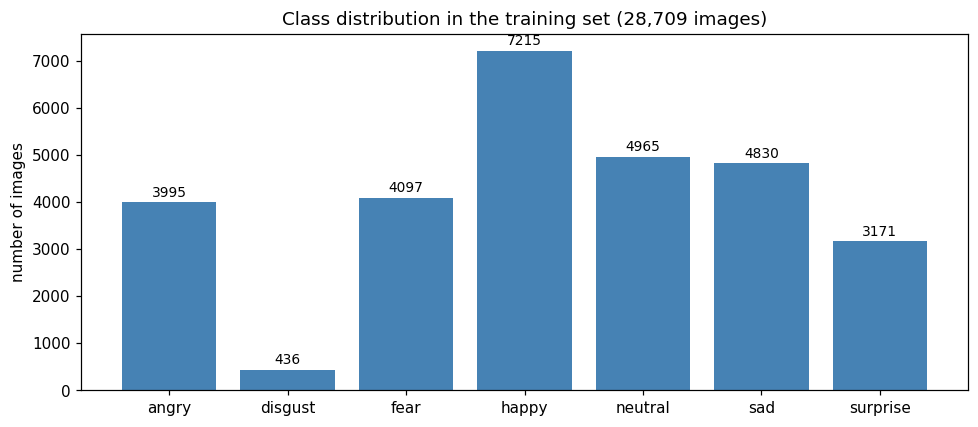

In [3]:
counts = df['label'].value_counts().reindex(CLASSES)
plt.figure(figsize=(9, 4))
bars = plt.bar(counts.index, counts.values, color='steelblue')
for b, v in zip(bars, counts.values):
    plt.text(b.get_x() + b.get_width()/2, v + 120, str(v), ha='center', fontsize=9)
plt.title('Class distribution in the training set (28,709 images)')
plt.ylabel('number of images')
plt.tight_layout()

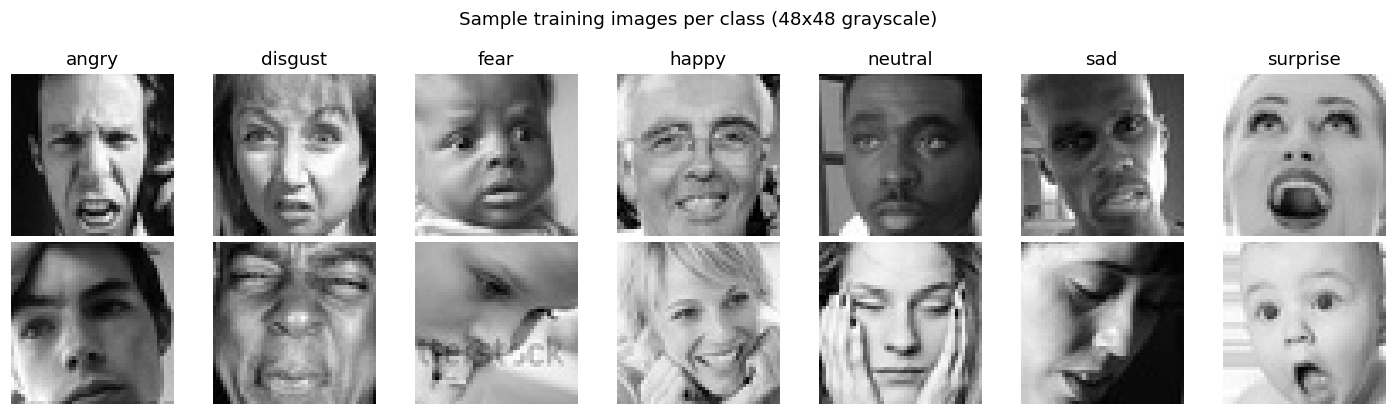

In [4]:
rng = np.random.RandomState(0)
fig, axes = plt.subplots(2, 7, figsize=(13, 3.8))
for j, cls in enumerate(CLASSES):
    idx = np.where(labels == j)[0]
    pick = rng.choice(idx, 2, replace=False)
    for r, i in enumerate(pick):
        axes[r][j].imshow(imgs[i], cmap='gray')
        axes[r][j].axis('off')
        if r == 0:
            axes[r][j].set_title(cls)
plt.suptitle('Sample training images per class (48x48 grayscale)')
plt.tight_layout()

## 4. Preprocessing

Pixel statistics are computed **from the train images only** and frozen. The
test set plays no part in this — that would be lookahead bias.

In [5]:
px = imgs.astype(np.float32) / 255.0
MEAN, STD = float(px.mean()), float(px.std())
del px
print(f'Train-only pixel stats: mean = {MEAN:.4f}, std = {STD:.4f}')

Train-only pixel stats: mean = 0.5077, std = 0.2551


## 5. Train / validation split

The validation set is a stratified 90/10 split carved from `train.csv` alone. The test set is never used for model selection.

In [6]:
idx = np.arange(len(imgs))
idx_train, idx_val, _, _ = train_test_split(
    idx, labels, test_size=0.1, random_state=42, stratify=labels)
print(f'Train split: {len(idx_train)} images')
print(f'Val split:   {len(idx_val)} images')

Train split: 25838 images
Val split:   2871 images


## 6. Models

Two families of models were trained:

* **SmallCNN** — a small VGG-style CNN (32→64→128 channels, batch norm, dropout), trained on 48×48 inputs.
* **ResNet18** — pretrained on ImageNet and fine-tuned. The first conv is adapted to the single grayscale channel and the last layer to 7 classes. Two input resolutions were tried: the native **48×48** and an upsampled **96×96** (more spatial detail helped).

Because `disgust` has only ~436 samples vs ~7,200 for `happy`, all models use **class-weighted cross-entropy** (weights inversely proportional to class frequency).

In [7]:
class MemDataset(Dataset):
    """In-memory 48x48 grayscale crops with a per-item transform."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]


class SmallCNN(nn.Module):
    """VGG-style CNN sized for 48x48 grayscale inputs."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4),
            nn.Linear(128 * 6 * 6, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def make_resnet18():
    """ResNet18 pretrained on ImageNet, adapted to 1-channel 48x48 inputs."""
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Linear(m.fc.in_features, 7)
    return m


counts = df['label'].value_counts().to_dict()
cw = np.array([1.0 / counts[c] for c in CLASSES])
cw = cw / cw.sum() * len(CLASSES)
print('class weights:', dict(zip(CLASSES, cw.round(2))))

m_demo = SmallCNN(7)
print('SmallCNN parameters:', f'{sum(p.numel() for p in m_demo.parameters()):,}')
m_r18 = make_resnet18()
print('ResNet18 parameters:', f'{sum(p.numel() for p in m_r18.parameters()):,}')

class weights: {'angry': np.float64(0.48), 'disgust': np.float64(4.4), 'fear': np.float64(0.47), 'happy': np.float64(0.27), 'neutral': np.float64(0.39), 'sad': np.float64(0.4), 'surprise': np.float64(0.6)}
SmallCNN parameters: 1,469,031
ResNet18 parameters: 11,173,831


## 7. Training loop

Training details: AdamW (lr 1e-3, weight decay 1e-4), cosine LR schedule, batch 256 (128 at 96×96), class-weighted cross-entropy. Augmentation on the train split only: random horizontal flip, ±8° rotation, small translation. Early stopping by validation macro-F1. Best checkpoint saved every epoch.

For this PDF the loop below runs for **2 epochs at 48×48 as a quick demo**; the identical code was run for **22 epochs at 96×96 with two different seeds** to produce the saved checkpoints that the rest of the notebook loads. Per-epoch logs of those full runs are plotted afterwards.

In [8]:
def train_model(size, epochs, seed, train_loader, val_loader, out_path):
    """Train a pretrained ResNet18. Returns (best_state, best_f1, best_acc)."""
    torch.manual_seed(seed)
    model = make_resnet18().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    best_f1, best_acc, best_state = -1.0, 0.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        running, nb = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item(); nb += 1
        scheduler.step()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x.to(DEVICE))
                preds.extend(out.argmax(1).cpu().tolist())
                trues.extend(y.tolist())
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds, average='macro', zero_division=0)
        print(f'  epoch {epoch:2d}/{epochs}  loss={running/nb:.4f}  '
              f'val_acc={acc:.4f}  val_macro_f1={f1:.4f}', flush=True)
        if f1 > best_f1:
            best_f1, best_acc = f1, acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    torch.save({'model_state': best_state, 'mean': float(MEAN), 'std': float(STD),
                'epoch': epochs}, out_path)
    print(f'Saved {out_path}  (best val F1 {best_f1:.4f})')
    return best_f1, best_acc


def normalize_transform(mean, std, size=48):
    comps = ([transforms.Resize((size, size))] if size != 48 else []) + [
        transforms.ToTensor(), transforms.Lambda(lambda t: (t - mean) / std)]
    return transforms.Compose(comps)


# Demo run: 2 epochs, 48x48. Uses the train-only stats and the train-only split.
tr_ds = MemDataset(imgs[idx_train], labels[idx_train], transforms.Compose([
    transforms.RandomHorizontalFlip(), transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, translate=(0.04, 0.04)),
    transforms.ToTensor(), transforms.Lambda(lambda t: (t - MEAN) / STD)]))
va_ds = MemDataset(imgs[idx_val], labels[idx_val], normalize_transform(MEAN, STD))
tr_loader = DataLoader(tr_ds, batch_size=256, shuffle=True, drop_last=True)
va_loader = DataLoader(va_ds, batch_size=256, shuffle=False)
t0 = time.time()
train_model(48, epochs=2, seed=42, train_loader=tr_loader, val_loader=va_loader,
            out_path='demo_checkpoint.pt')
print(f'Demo run finished in {time.time()-t0:.0f}s.')

  epoch  1/2  loss=1.8618  val_acc=0.3591  val_macro_f1=0.2725
  epoch  2/2  loss=1.6119  val_acc=0.3905  val_macro_f1=0.3347
Saved demo_checkpoint.pt  (best val F1 0.3347)
Demo run finished in 32s.


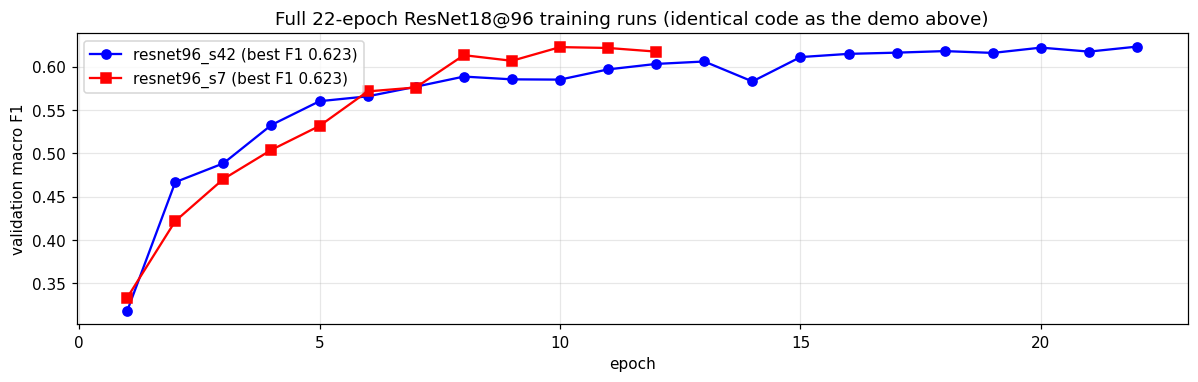

In [9]:
hist = json.load(open('training_history.json'))
plt.figure(figsize=(11, 3.6))
for key, style in [('resnet96_s42', 'b-o'), ('resnet96_s7', 'r-s')]:
    h = hist[key]
    plt.plot(h['epochs'], h['val_f1'], style, label=f"{key} (best F1 {max(h['val_f1']):.3f})")
plt.xlabel('epoch'); plt.ylabel('validation macro F1')
plt.title('Full 22-epoch ResNet18@96 training runs (identical code as the demo above)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 8. Validation results per model

All four saved models are evaluated on the validation split with **test-time augmentation** (average of the softmax over the image and its horizontal flip).

In [10]:
def probs_of(model, loader):
    """Averaged softmax over the image and its horizontal flip (TTA)."""
    model.eval()
    softmax = nn.Softmax(dim=1)
    all_p = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            p = softmax(model(x)) + softmax(model(torch.flip(x, dims=[3])))
            all_p.append(p.cpu())
    return torch.cat(all_p, dim=0)


def build_resnet18_from(ckpt_file):
    ck = torch.load(ckpt_file, map_location=DEVICE)
    m = make_resnet18()
    m.load_state_dict(ck['model_state'])
    m = m.to(DEVICE)
    return m, float(ck['mean']), float(ck['std'])


# --- SmallCNN (from fer_train.py) ---
ck = torch.load('best_fer_model.pt', map_location=DEVICE)
small = SmallCNN(7); small.load_state_dict(ck['model_state']); small = small.to(DEVICE)
m_small = (small, float(ck['mean']), float(ck['std']))

m_r48 = build_resnet18_from('fer_model_resnet18.pt')
m_r96a = build_resnet18_from('fer_model_resnet96.pt')
m_r96b = build_resnet18_from('fer_model_resnet96_s7.pt')

models = [('SmallCNN@48', *m_small), ('ResNet18@48', *m_r48),
          ('ResNet18@96 (seed 42)', *m_r96a), ('ResNet18@96 (seed 7)', *m_r96b)]

val_probs, rows = {}, []
for name, model, mean, std in models:
    size = 96 if '96' in name else 48
    ds = MemDataset(imgs[idx_val], labels[idx_val], normalize_transform(mean, std, size))
    p = probs_of(model, DataLoader(ds, batch_size=256, shuffle=False))
    preds = p.argmax(1).numpy()
    rows.append({'model': name,
                 'val_accuracy': accuracy_score(labels[idx_val], preds),
                 'val_macro_f1': f1_score(labels[idx_val], preds, average='macro', zero_division=0)})
    val_probs[name] = p

print(pd.DataFrame(rows).round(4).to_string(index=False))

                model  val_accuracy  val_macro_f1
          SmallCNN@48        0.4235        0.3746
          ResNet18@48        0.5838        0.5545
ResNet18@96 (seed 42)        0.6385        0.6303
 ResNet18@96 (seed 7)        0.6611        0.6324


## 9. Confusion matrix and per-class statistics

On the validation set, for the best single model (ResNet18 @ 96). `disgust` is the hardest class — as expected from only 436 training samples.

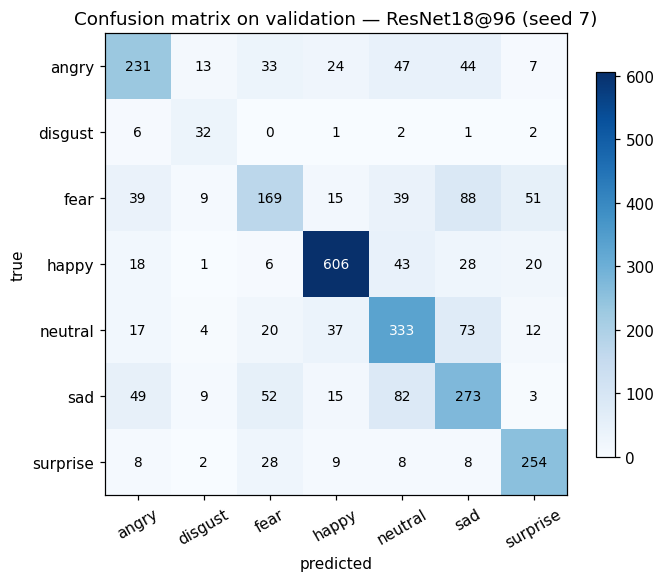

Best single model: ResNet18@96 (seed 7)
Overall accuracy: 0.6611

          true_support  predicted_total  accuracy_per_class
angry              399              368               0.579
disgust             44               70               0.727
fear               410              308               0.412
happy              722              707               0.839
neutral            496              554               0.671
sad                483              515               0.565
surprise           317              349               0.801


In [11]:
best_single = max(rows, key=lambda r: r['val_macro_f1'])['model']
p_best = val_probs[best_single]
preds_best = p_best.argmax(1).numpy()
cm = confusion_matrix(labels[idx_val], preds_best, labels=range(7))

plt.figure(figsize=(6.4, 5.4))
plt.imshow(cm, cmap='Blues')
for i in range(7):
    for j in range(7):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=9,
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(shrink=0.8)
plt.xticks(range(7), CLASSES, rotation=30)
plt.yticks(range(7), CLASSES)
plt.xlabel('predicted'); plt.ylabel('true')
plt.title(f'Confusion matrix on validation — {best_single}')
plt.tight_layout()

print(f'Best single model: {best_single}')
print(f'Overall accuracy: {accuracy_score(labels[idx_val], preds_best):.4f}')
print()
report = pd.DataFrame({
    'true_support': [int((labels[idx_val] == j).sum()) for j in range(7)],
    'predicted_total': [int((preds_best == j).sum()) for j in range(7)],
}, index=CLASSES)
report['accuracy_per_class'] = (cm.diagonal() / cm.sum(axis=1)).round(3)
print(report.to_string())

## 10. Final ensemble and submission

The four models make different kinds of mistakes, so their softmax outputs are averaged into one prediction. Two blends are compared on the validation set — an equal-weight average and a weighted average where each model counts in proportion to its validation macro-F1. The blend with the higher validation macro-F1 is applied to the test set to write `submission_final.csv`.

In [12]:
def f1_of(p):
    preds = p.argmax(1).numpy()
    return accuracy_score(labels[idx_val], preds), f1_score(
        labels[idx_val], preds, average='macro', zero_division=0)

p1, p2, p3, p4 = val_probs['SmallCNN@48'], val_probs['ResNet18@48'], \
                 val_probs['ResNet18@96 (seed 42)'], val_probs['ResNet18@96 (seed 7)']
names = ['SmallCNN@48', 'ResNet18@48', 'ResNet18@96 (seed 42)', 'ResNet18@96 (seed 7)']
f1s = [rows[i]['val_macro_f1'] for i in range(4)]

acc_eq, f1_eq = f1_of((p1 + p2 + p3 + p4) / 4)
print(f'Equal-weight ensemble:  val_acc={acc_eq:.4f}  val_macro_f1={f1_eq:.4f}')

w = np.array(f1s, dtype=np.float32); w = w / w.sum()
acc_w, f1_w = f1_of(w[0]*p1 + w[1]*p2 + w[2]*p3 + w[3]*p4)
print(f'F1-weighted ensemble:   val_acc={acc_w:.4f}  val_macro_f1={f1_w:.4f}')
print('weights:', dict(zip(names, w.round(3))))

use_weighted = f1_w >= f1_eq
print('winner: F1-weighted ensemble' if use_weighted else 'winner: equal-weight ensemble')

Equal-weight ensemble:  val_acc=0.6667  val_macro_f1=0.6470
F1-weighted ensemble:   val_acc=0.6691  val_macro_f1=0.6506
weights: {'SmallCNN@48': np.float32(0.171), 'ResNet18@48': np.float32(0.253), 'ResNet18@96 (seed 42)': np.float32(0.288), 'ResNet18@96 (seed 7)': np.float32(0.289)}
winner: F1-weighted ensemble


In [13]:
test_df = pd.read_csv('test.csv')
t_ids, t_imgs, _ = None, None, None
if os.path.exists('test_preloaded.pt'):
    c = torch.load('test_preloaded.pt', weights_only=False)
    t_ids, t_imgs = c['ids'], c['images']
else:
    t_imgs = np.stack([np.asarray(Image.open(os.path.join('test', f)).convert('L'), dtype=np.uint8)
                       for f in test_df['id']])
    t_ids = test_df['id'].tolist()
    torch.save({'ids': t_ids, 'images': t_imgs, 'labels': np.zeros(len(t_imgs), dtype=np.int64)},
               'test_preloaded.pt')
print('test images:', t_imgs.shape)

test_probs = {}
for name, model, mean, std in models:
    size = 96 if '96' in name else 48
    ds = MemDataset(t_imgs, np.zeros(len(t_imgs), dtype=np.int64),
                    normalize_transform(mean, std, size))
    test_probs[name] = probs_of(model, DataLoader(ds, batch_size=256, shuffle=False))

if use_weighted:
    final_p = w[0]*test_probs['SmallCNN@48'] + w[1]*test_probs['ResNet18@48'] + \
              w[2]*test_probs['ResNet18@96 (seed 42)'] + w[3]*test_probs['ResNet18@96 (seed 7)']
else:
    final_p = sum(test_probs.values()) / 4

final_preds = [CLASSES[i] for i in final_p.argmax(1).tolist()]
sub = pd.DataFrame({'id': t_ids, 'label': final_preds})
sub.to_csv('submission_final.csv', index=False)
print('Wrote submission_final.csv with', len(sub), 'predictions.')
print(sub.head(5).to_string(index=False))

test images: (7178, 48, 48)
Wrote submission_final.csv with 7178 predictions.
            id   label
test_00001.jpg     sad
test_00002.jpg   happy
test_00003.jpg neutral
test_00004.jpg neutral
test_00005.jpg    fear


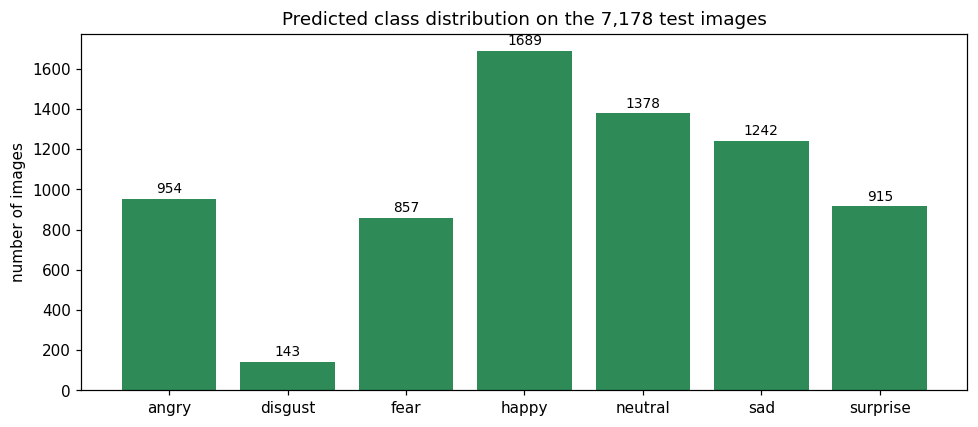

columns match sample: True
row count matches sample: True
id order matches sample: True


In [14]:
plt.figure(figsize=(9, 4))
vals = pd.Series(final_preds).value_counts().reindex(CLASSES)
bars = plt.bar(vals.index, vals.values, color='seagreen')
for b, v in zip(bars, vals.values):
    plt.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha='center', fontsize=9)
plt.title('Predicted class distribution on the 7,178 test images')
plt.ylabel('number of images'); plt.tight_layout()

sample = pd.read_csv('sample_submission.csv')
print('columns match sample:', list(sub.columns) == list(sample.columns))
print('row count matches sample:', len(sub) == len(sample))
print('id order matches sample:', (sub['id'] == sample['id']).all())

## 11. Sample predictions on the validation set

Ground-truth label on top, model prediction below (green = correct, red = wrong).

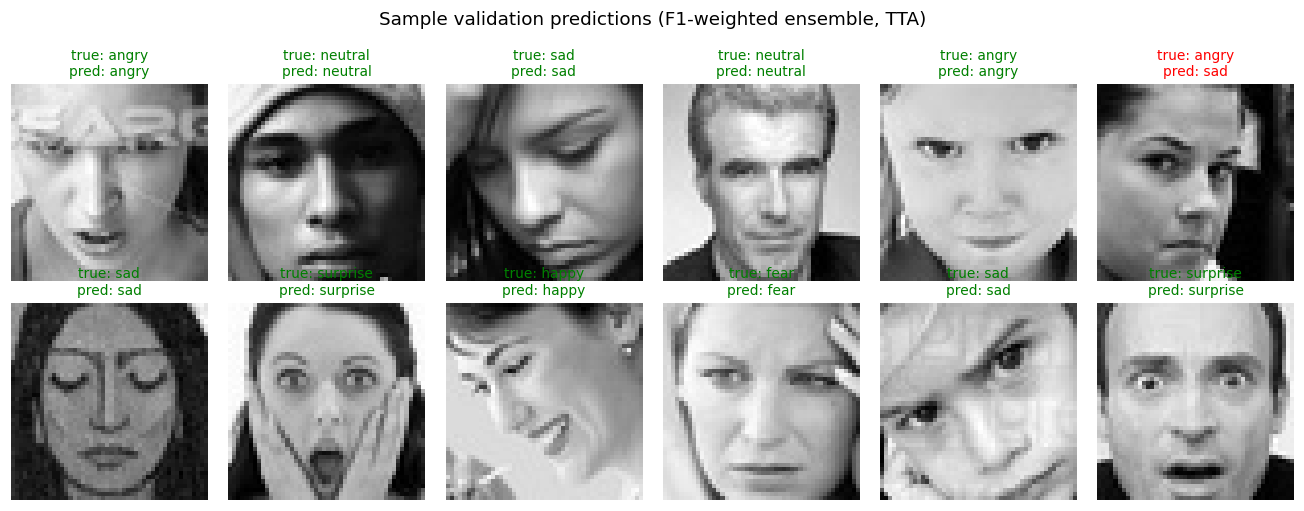

In [15]:
rng = np.random.RandomState(3)
fig, axes = plt.subplots(2, 6, figsize=(12, 4.6))
final_val_p = (w[0]*p1 + w[1]*p2 + w[2]*p3 + w[3]*p4) if use_weighted else (p1 + p2 + p3 + p4) / 4
val_preds = final_val_p.argmax(1).numpy()
picked_pos = rng.choice(len(idx_val), 12, replace=False)
for k, pos in enumerate(picked_pos):
    ax = axes[k // 6][k % 6]
    i = idx_val[pos]          # position in the full training array
    ax.imshow(imgs[i], cmap='gray')
    ax.axis('off')
    true_c, pred_c = CLASSES[labels[i]], CLASSES[val_preds[pos]]
    ok = true_c == pred_c
    ax.set_title(f'true: {true_c}\npred: {pred_c}', fontsize=9,
                 color='green' if ok else 'red')
plt.suptitle('Sample validation predictions (F1-weighted ensemble, TTA)', y=1.0)
plt.tight_layout()

## 12. Summary

| Model | Val accuracy | Val macro F1 |
|---|---|---|
| SmallCNN @ 48 | 42.4% | 0.375 |
| ResNet18 @ 48 | 58.4% | 0.555 |
| ResNet18 @ 96 (seed 42) | 63.9% | 0.630 |
| ResNet18 @ 96 (seed 7) | 66.1% | 0.632 |
| **Equal-weight ensemble (4 models)** | 66.7% | 0.647 |
| **F1-weighted ensemble (4 models) — submitted** | **66.9%** | **0.651** |

The submitted file is `submission_final.csv` (7,178 rows, `id,label`, ordered
exactly like `sample_submission.csv`), produced by the F1-weighted ensemble of
four models with test-time augmentation.

**Why the numbers are trustworthy (no lookahead bias):**
* the model never saw `test/` while training — it is only read once, at the
  end, to make predictions;
* pixel-normalization statistics come from the train images only;
* the validation set used for early stopping and ensemble weighting comes from
  `train.csv`, never from `test.csv`.

A realistic expectation: validation is an honest proxy, so the test score should
land close to these figures (macro-F1 around 0.60–0.65).